# Loss curves visualisation 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
plt.rcParams.update({
    "font.size": 12,              # base font size
    "axes.titlesize": 14,         # title font
    "axes.labelsize": 13,         # x and y labels
    "xtick.labelsize": 11,        # x ticks
    "ytick.labelsize": 11,        # y ticks
    "legend.fontsize": 11,        # legend
})

#plt.rcParams['figure.constrained_layout.use'] = True

In [ ]:
# EXPERIMENT CONFIGURATION
# Date identifier for this evaluation run (should match training date)
date = '26_05_25'
path = '/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/bimodal_VAE/' + date

In [ ]:
# Load training history: loss curves and learning rate schedule
# These files are saved during model training (see petVAE_model_training.ipynb)
v_loss = np.load(path + "/val_loss.npy")  # Validation loss per epoch
t_loss = np.load(path + "/train_loss.npy")  # Training loss per epoch
lr = np.load(path + "/lr.npy")  # Learning rate per epoch

In [ ]:
# DEBUG CELL - Check minimum validation loss
# Uncomment to find the minimum validation loss value
#v_loss.min()

0.0018739780574840979

In [ ]:
# Find epoch with minimum validation loss (best model checkpoint)
# This helps identify when the best model was saved during training
x = pd.DataFrame(v_loss)
min_value = x.min().iloc[0]          # Minimum validation loss value
min_index = x.idxmin().iloc[0]       # Epoch index with minimum loss
print(min_value)
print(min_index)

In [ ]:
len(v_loss)

In [ ]:
#color palette
CB_color_cycle = ["#999999", "#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7"]

In [ ]:
# VISUALIZE LOSS CURVES
# Plot training and validation loss over epochs (log scale)
# Log scale helps visualize loss trends when values span multiple orders of magnitude

plt.plot(np.log(t_loss), color=CB_color_cycle[1], linewidth=2.5, label='Train')
plt.plot(np.log(v_loss), color=CB_color_cycle[2], linewidth=2.5, label='Validation')

plt.title('Model Loss', size=20)
plt.ylabel('ln(loss)', size=20)
plt.xlabel('Epoch', size=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

plt.legend(['Train', 'Validation'], loc='upper right', fontsize=18)

plt.savefig(path + '/loss_curves_' + date + '.png', bbox_inches='tight')
plt.savefig(path + '/loss_curves_' + date + '.svg', format='svg',transparent=True, bbox_inches='tight')
plt.show()




# Reconstruction visualisation

In [9]:
from addl_models_bimodel_pytorch import VAE_1modality_PET

import pandas as pd
import nibabel as nib

import torch
import torch.utils.data
from torch import nn, optim
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms
#from torchvision.utils import save_image

from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
import seaborn as sns

#import image_similarity_measures.evaluate as evaluate

[NbConvertApp] Converting notebook addl_models_bimodel_pytorch.ipynb to script
[NbConvertApp] Writing 51888 bytes to addl_models_bimodel_pytorch.py


# SSIM - sensitive to noise
Structural Similar Index Measure (SSIM) quantifies image quality degradation caused by processing, such as data compression, or by losses in data transmission. SSIM is based on visible structures in the image. In order words SSIM actually measures the perceptual difference between two similar images. The algorithm does not judge which of the two is better. However, that can be inferred from knowing which is the original image and which has been subjected to additional processing, such as data compression. The SSIM value is between −1 and 1 with 1 indicating perfect structural similarity.



In [10]:
#meta2=  pd.read_csv(path + '/metafile_shuffled_'+ date+'.csv')
meta2=  pd.read_csv(path + '/metafile_shuffled_'+ date+'.csv')

In [12]:
# Prep brain mask
brain_mask = nib.load('/csc/epitkane/home/atagmazi/tpl-MNI152NLin6Asym_res-01_desc-brain_T1w.nii.gz').get_fdata()
brain_mask[brain_mask != 0] = 1


In [ ]:
# DATA PARTITIONING: Split data into train/validation/test sets

# Split structure:
# - Train: First 80% of train set (64% of total data)
# - Validation: Last 20% of train set (16% of total data)  
# - Test: Remaining 20% of total data

train_size = 0.8
train_end = int(len(meta2)*train_size)

data_train = meta2[:train_end]
data_test = meta2[train_end:]

data_partition = dict()

# Split train set further into train (80%) and validation (20%)
t = int(0.8*np.shape(data_train)[0])
v = int(0.2*np.shape(data_train)[0])  # Not used, calculated for reference

# Create partitions using sequential indexing
# WARNING: Sequential split without shuffle can cause data leakage
data_partition['train'] = meta2.loc[:t,:].reset_index(drop=True)
data_partition['validation'] = meta2.loc[t+1:train_end,:].reset_index(drop=True)
data_partition['test'] = meta2.loc[train_end+1:,:].reset_index(drop=True)

data_partition['all'] = meta2.loc[:,:].reset_index(drop=True)


In [15]:
stat = np.load("/csc/epitkane/home/atagmazi/ADDL_pipeline/scripts/stats_train.npz")
p_quant90 = stat['p_quant90']
m_quant90 = stat['m_quant90']

p_quant95 = stat['p_quant95']
m_quant95 = stat['m_quant95']

p_quant99 = stat['p_quant99']
m_quant99 = stat['m_quant99']

p_quant999 = stat['p_quant999']
m_quant999 = stat['m_quant999']

p_std = stat['p_std']
m_std = stat['m_std']

p_mean_clip = stat['p_mean_clip']
m_mean_clip = stat['m_mean_clip']
p_std_clip = stat['p_std_clip']
m_std_clip = stat['m_std_clip']

p_min_clip = stat['p_mim_clip']
m_min_clip = stat['m_min_clip']
p_max_clip = stat['p_max_clip']
m_max_clip = stat['m_max_clip']

In [16]:
stat

In [ ]:
class PETSliceDataset(Dataset):
    def __init__(self, list_IDs_pet, slice_axis=2, brain_mask=None, 
                 pet_minimum= p_min_clip, pet_maximum=p_max_clip,
                 mri_minimum= m_min_clip, mri_maximum=m_max_clip,
                 pet_quant = p_quant999,mri_quant= m_quant999, 
                 pet_mean = p_mean_clip,mri_mean = m_mean_clip,
                 pet_std = p_std_clip,mri_std = m_std_clip,
                 sagittal_dim=182, coronal_dim=218, axial_dim=182):
        """
        PyTorch Dataset for paired 2D slices of PET and MRI scans.
        """
        self.list_IDs_pet = list_IDs_pet
        
        self.slice_axis = slice_axis  # 0 = sagittal, 1 = coronal, 2 = axial
        self.brain_mask = brain_mask
        
        self.pet_minimum = pet_minimum
        self.pet_maximum = pet_maximum
        self.pet_quant = pet_quant
        self.pet_mean = pet_mean
        self.pet_std = pet_std
        self.mri_minimum = mri_minimum
        self.mri_maximum = mri_maximum
        self.mri_quant = mri_quant
        self.mri_mean = mri_mean
        self.mri_std = mri_std
        
        self.sagittal_dim = sagittal_dim
        self.coronal_dim = coronal_dim
        self.axial_dim = axial_dim
        self.slices = self.load_all_slices()  # Preload slice paths
        self.indices = list(range(len(self.slices)))

    def load_all_slices(self):
        """Extracts and pairs 2D slices from all PET/MRI scans."""
        slices = []
        slice_id = 0
        for pet_path in zip(self.list_IDs_pet):
            if self.slice_axis == 0:  # Sagittal
                num_slices = slice_id + self.sagittal_dim 
            elif self.slice_axis == 1:  # Coronal
                num_slices = slice_id + self.coronal_dim 
            else:  # Axial (default)
                num_slices = slice_id + self.axial_dim 

            for within_img_num, i in enumerate(range(slice_id, num_slices)):
                slices.append((pet_path, i, within_img_num))  # Store slice index
            slice_id = num_slices
        return slices

    def __len__(self):
        """Returns the number of slices."""
        return len(self.slices)

    def __data_generation(self, batch_slices):
        """Generates one batch of 2D slices."""
        pet_slices = []
        pet_ids = []
        batch_data = []

        #pet_path, slice_idx, slice_num_inimg = batch_slices[0]
        for slice_info in batch_slices:
            pet_path, slice_idx, slice_num_inimg = slice_info  # Ensure correct unpacking
            pet_path = pet_path[0]
            if not isinstance(pet_path, str):  
                print(pet_path)
                print(slice_idx)
                print(slice_num_inimg)
                raise ValueError(f"Expected pet_path to be a string, got {type(pet_path)}")
                
        
        img_pet = nib.load(pet_path).get_fdata()
        

            # Extract the corresponding 2D slice
        if self.slice_axis == 0:  # Sagittal
            pet_slice = img_pet[slice_num_inimg, :, :]
            
            if self.brain_mask is not None:
                bm = self.brain_mask[slice_num_inimg, :, :]
                pet_slice *= bm
                
                    
        elif self.slice_axis == 1:  # Coronal
            pet_slice = img_pet[:, slice_num_inimg, :]
            
            if self.brain_mask is not None:
                bm = self.brain_mask[:, slice_num_inimg, :]
                pet_slice *= bm
            
            
        else:  # Axial (default)
            pet_slice = img_pet[:, :, slice_num_inimg]
            
            if self.brain_mask is not None:
                bm = self.brain_mask[:, :, slice_num_inimg]
                pet_slice *= bm
                

            # Skip slices with NaNs or empty regions
        #if np.isnan(pet_slice).any() and np.isnan(mri_slice).any():
        #    return None, None, None, None 
        #if np.max(pet_slice) == 0 and np.max(mri_slice) == 0:
        #    return None, None, None, None 
            # Skip empty slices
            #if pet_slice.size == 0 or mri_slice.size == 0:
            #    continue  # Skip this slice

            # Normalize if necessary (optional step, currently not applied)
        
        pet_norm = self.min_max_normalize(np.asarray(pet_slice, dtype=np.float32), float(self.pet_quant), self.pet_minimum, self.pet_maximum)
        
        pet_norm = np.clip(pet_norm, 0, 1)
        
        # Convert to NumPy arrays
        
        batch_data = np.array(pet_norm, dtype=np.float32)
        #print(batch_data.shape[0])
        batch_data = batch_data.reshape(1, batch_data.shape[0],  batch_data.shape[1])
        #print(batch_data.shape)
        #if len(batch_data) == 0:
            #return None, None, None
        

        # Convert to tensor
        return batch_data, pet_path, slice_num_inimg 

    def __getitem__(self, index):
        """Generates one slice of 2D images (per slice, not batch)."""
        # Get a single slice metadata
        pet_path, slice_idx, slice_num_inimg = self.slices[index]
        
        # Generate single slice data
        X, pet_ids, slice_n = self.__data_generation([(pet_path, slice_idx, slice_num_inimg)])
        X = torch.tensor(X, dtype=torch.float32)
        #print(X.shape)


        return { 'image': X, 'pet_ID': pet_ids, 'slice_number': slice_n }

    
    #def quantile_norm(self, image, quantile, mean, std):
        #image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        #image = np.clip(image, 0, quantile)  # Clip values above quantile
        #image = (image - mean) / (std + 1e-8)  # Avoid division by zero
        #return image
    def min_max_normalize(self,image,quantile, min_val, max_val):
        image = np.asarray(image, dtype=np.float32).copy()  # Ensure array and prevent in-place modification
        image = np.clip(image, 0, quantile)  # Clip values above quantile
        return (image - min_val) / (max_val - min_val + 1e-8)  # Avoid division by zero


In [ ]:
# Creating datasets for visualization
train_dataset = PETSliceDataset(list_IDs_pet = data_partition['train']['PET_PATH_normalised'], brain_mask = brain_mask)

validation_dataset = PETSliceDataset(list_IDs_pet = data_partition['validation']['PET_PATH_normalised'], brain_mask = brain_mask)

test_dataset = PETSliceDataset(list_IDs_pet = data_partition['test']['PET_PATH_normalised'], brain_mask = brain_mask) #99:100 19:20


In [43]:
# creating dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=2,
                        shuffle=False, num_workers=0)

validation_dataloader = DataLoader(validation_dataset, batch_size=2,
                        shuffle=False, num_workers=0)

test_dataloader = DataLoader(test_dataset, batch_size=182,
                        shuffle=False, num_workers=0)

In [44]:
#model_up = CCVAE(60*10*12*9, latent_size =500, class_size =3)
model_up=torch.load(path+"/best_model.pth",map_location=torch.device("cuda:0" if torch.cuda.is_available() else "cpu"))
model_up.eval()

VAE_1modality_PET(
  (conv): Sequential(
    (0): ConvBlock(
      (conv): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (1): ConvBlock(
      (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dense_mean): Linear(in_features=262144, out_features=64, bias=True)
  (dense_log_var): Linear(in_features=262144, out_features=64, bias=True)
  (dense): Linear(in_features=64, out_features=262144, bias=True)
  (deconv): Sequential(
    (0): DeconvBlock(
      (deconv): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (1): DeconvBlock(
      (deconv): ConvTranspose2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (activation): LeakyReLU(negative_slope=0.01)
    )
    (2): DeconvBlock(

In [45]:
for batch_idx, data in enumerate(test_dataloader):
    print(data['image'].shape)

torch.Size([182, 1, 182, 218])


In [ ]:
def scans_reconstruction(dataloader):
    """
    Reconstruct all scans in a dataloader and return original and reconstructed arrays.
    
    Process:
    1. Process each batch through the model
    2. Concatenate all batches into full volume arrays
    3. Limit to first 91 batches (for memory efficiency)
    
    Parameters:
    - dataloader: DataLoader containing scans to reconstruct
    
    Returns:
    - orig_scan: Original scan array (concatenated batches)
    - recon_scan: Reconstructed scan array (concatenated batches)
    """
    for batch_idx, data in enumerate(dataloader):
        # Prepare batch data
        data_batch_train = data['image'].type(torch.FloatTensor).to("cuda:0" if torch.cuda.is_available() else "cpu")
        
        # Forward pass: reconstruct images
        image_recon_train = model_up(data_batch_train)
        
        # Concatenate batches into full volume arrays
        if batch_idx == 0:
            orig_scan = data_batch_train.detach().numpy()
            recon_scan = image_recon_train[0].detach().numpy()  # Extract reconstruction (first element)
        else:
            orig_scan = np.concatenate([orig_scan, data_batch_train.detach().numpy()], axis=0)
            recon_scan = np.concatenate([recon_scan, image_recon_train[0].detach().numpy()], axis=0)
        
        # Limit to first 91 batches (for memory efficiency)
        # This processes approximately 91 slices (one full volume)
        if batch_idx >= 90:  # 0-indexed, so this captures batches 0-90 (91 batches)
            break
    
    return orig_scan, recon_scan


In [47]:
#train_or, train_rec = scans_reconstruction(train_dataloader)
#val_or, val_rec = scans_reconstruction(validation_dataloader)
test_or, test_rec = scans_reconstruction(test_dataloader)

In [ ]:
plt.hist(train_or[:,0,:,:].flatten(), bins = 100)

In [ ]:
plt.hist(train_rec[:,0,:,:].flatten(), bins = 100)

In [48]:
ssim_slice_train = []
ssim_slice_val = []
ssim_slice_test = []
def ssim_function(original_img, recon_img):
    pet = []
    mri = []
    for i in range(original_img.shape[0]):
        #data_range_pet = max(original_img[i][0].max() - original_img[i][0].min(), 
        #                 recon_img[i][0].max() - recon_img[i][0].min())
        
        pet.append(float(ssim(original_img[i][0], recon_img[i][0], data_range=1)))

        '''data_range_mri = max(original_img[i][1].max() - original_img[i][1].min(), 
                         recon_img[i][1].max() - recon_img[i][1].min())
        
        mri.append(float(ssim(original_img[i][1], recon_img[i][1], data_range=data_range_mri)))'''
    return pet


In [49]:
def psnr_function(original_img, recon_img):
    pet = []
    mri = []
    for i in range(original_img.shape[0]):
        #data_range_pet = max(original_img[i][0].max() - original_img[i][0].min(), 
        #                 recon_img[i][0].max() - recon_img[i][0].min())
        
        pet.append(float(psnr(original_img[i][0], recon_img[i][0], data_range=1)))

        '''data_range_mri = max(original_img[i][1].max() - original_img[i][1].min(), 
                         recon_img[i][1].max() - recon_img[i][1].min())
        
        mri.append(float(psnr(original_img[i][1], recon_img[i][1], data_range=data_range_mri)))'''
    return pet

In [51]:
#train_pet_ssim = ssim_function(train_or,train_rec)
#val_pet_ssim =ssim_function(val_or,val_rec)
test_pet_ssim =ssim_function(test_or,test_rec)

In [52]:
#train_pet_psnr = psnr_function(train_or,train_rec)
#val_pet_psnr =psnr_function(val_or,val_rec)
test_pet_psnr =psnr_function(test_or,test_rec)

In [40]:
plt.rcParams.update({
    "font.size": 16,              # base font size
    "axes.titlesize": 16,         # title font
    "axes.labelsize": 18,         # x and y labels
    "xtick.labelsize": 16,        # x ticks
    "ytick.labelsize": 16,        # y ticks
    "legend.fontsize": 15        # legend
})


def plot_slices(original_scan, reconstruction_scan,ssim_pet,psnr_pet, name):
    fig = plt.figure(figsize=(12,6))
    index1 = [1,3]
    index2 = [2,4]
    start = 0
    for num, i in enumerate([45,90]):
        
        fig.add_subplot(2, 2, index1[num])
        plt.imshow(np.rot90(original_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        if index1[num] == 1:
            plt.title('Original scan')
        
        fig.add_subplot(2,2, index2[num])
        plt.imshow(np.rot90(reconstruction_scan[i,0,:,:]), vmin=0, vmax=1)
        plt.axis('off')
        plt.text(0.95, 0.05, "SSIM="+str(round(ssim_pet[i],2)), color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        plt.text(0.95, 0.85, "PSNR="+str(round(psnr_pet[i],2)), color='white', ha='right', va='bottom', transform=plt.gca().transAxes)
        if index2[num] == 2:
            plt.title('Reconstructed scan')
        
        
        plt.subplots_adjust(wspace=-0.7, hspace=0.2) 
        
        #print(ssim_pet[i])
        plt.axis('off')
        plt.savefig(path+name+date+'.png', bbox_inches='tight')  # Save as PNG with 300 DPI
        plt.savefig(path+name+date+'.svg', format='svg',transparent=True, bbox_inches='tight')  

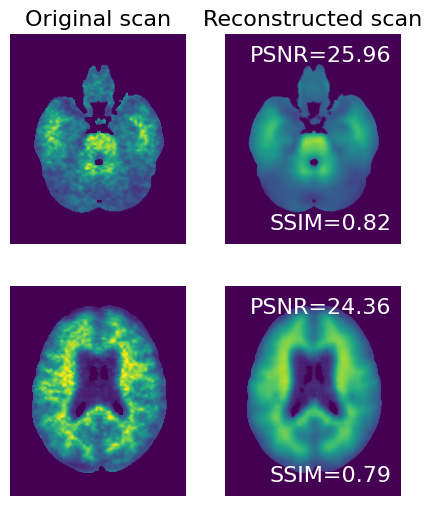

In [41]:
plot_slices(test_or,test_rec,test_pet_ssim,test_pet_psnr,'/slices_recon_test_sample_9siemens')

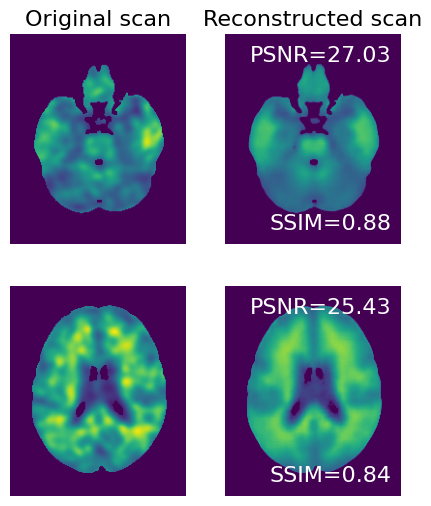

In [53]:
plot_slices(test_or,test_rec,test_pet_ssim,test_pet_psnr,'/slices_recon_test_sample_19philips')

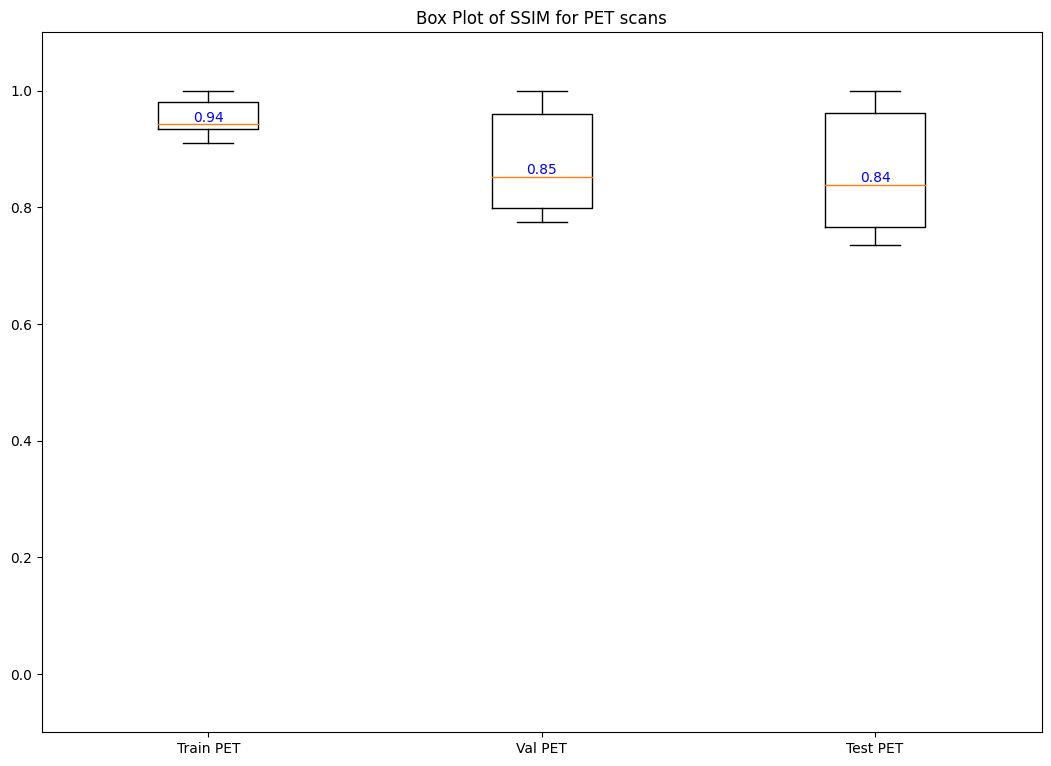

In [63]:
data = [train_pet_ssim, val_pet_ssim, test_pet_ssim]

fig = plt.figure(figsize=(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title('Box Plot of SSIM for PET scans')
# Creating plot
bp = ax.boxplot(data)

# Adding labels to x-axis
ax.set_xticklabels(['Train PET', 'Val PET', 'Test PET'])

# Setting the y-axis range from 0 to 1
ax.set_ylim(-0.1, 1.1)
for i, dataset in enumerate(data, start=1):
    median_value = np.median(dataset)
    # Adding text annotation for the average value on the box plot
    ax.text(i, median_value, f'{median_value:.2f}', ha='center', va='bottom', fontsize=10, color='blue')

# Show the plot

plt.savefig(path+'/SSIM_boxplots_'+date+'.png', bbox_inches='tight') 
plt.show()

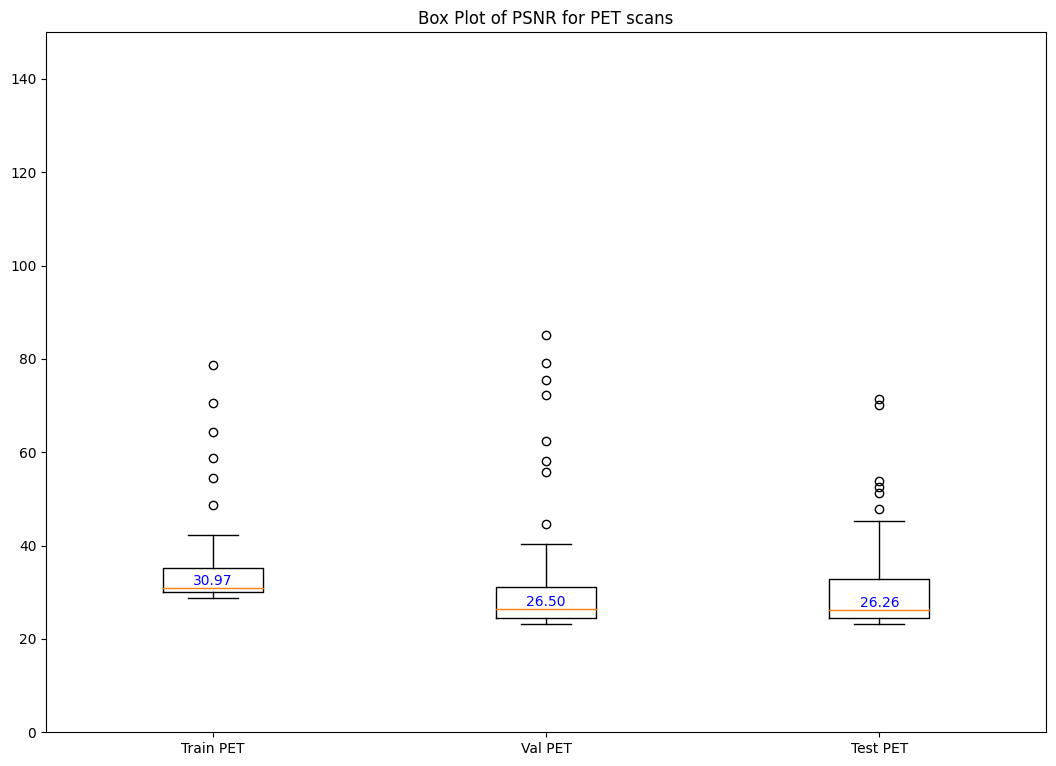

In [64]:
data = [train_pet_psnr, val_pet_psnr, test_pet_psnr]

fig = plt.figure(figsize=(10, 7))

# Creating axes instance
ax = fig.add_axes([0, 0, 1, 1])
ax.set_title('Box Plot of PSNR for PET scans')
# Creating plot
bp = ax.boxplot(data)

# Adding labels to x-axis
ax.set_xticklabels(['Train PET', 'Val PET', 'Test PET'])

# Setting the y-axis range from 0 to 1
ax.set_ylim(0, 150)
for i, dataset in enumerate(data, start=1):
    median_value = np.median(dataset)
    # Adding text annotation for the average value on the box plot
    ax.text(i, median_value, f'{median_value:.2f}', ha='center', va='bottom', fontsize=10, color='blue')

# Show the plot

plt.savefig(path+'/PSNR_boxplots_'+date+'.png', bbox_inches='tight') 
plt.show()